In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

In [4]:
df = pd.read_csv("phones.csv")

In [ ]:
df

<Axes: >

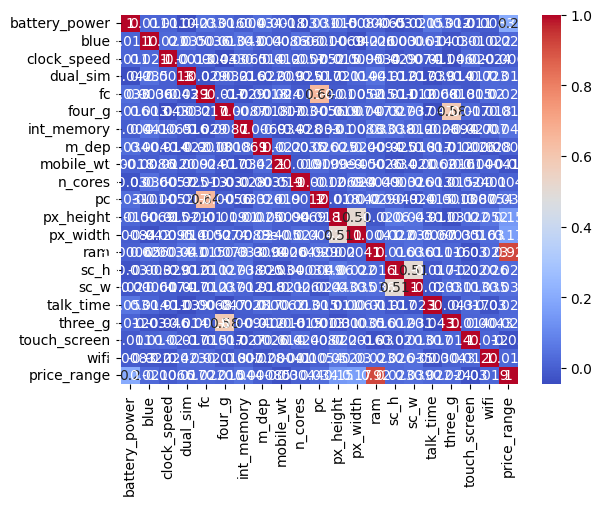

In [6]:
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

In [7]:
y = df["price_range"]
X = df.drop("price_range", axis=1)

In [8]:
X.max()

battery_power    1998.0
blue                1.0
clock_speed         3.0
dual_sim            1.0
fc                 19.0
four_g              1.0
int_memory         64.0
m_dep               1.0
mobile_wt         200.0
n_cores             8.0
pc                 20.0
px_height        1960.0
px_width         1998.0
ram              3998.0
sc_h               19.0
sc_w               18.0
talk_time          20.0
three_g             1.0
touch_screen        1.0
wifi                1.0
dtype: float64

In [28]:
# Train_test
X = sm.add_constant(X)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Standardize features where values are Xnot 0 or 1
standardize = X_train.columns[(X_train.max()-X_train.min()) > 1]

In [29]:
X_train[standardize] = scaler.fit_transform(X_train[standardize])
X_test[standardize] = scaler.transform(X_test[standardize])

In [30]:
X_train

,const,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
968,1.0,1.548360,0,-1.236230,1,0.620111,0,0.754832,0.5,1.425710,...,0.020269,0.275712,1.181997,-0.580476,-0.528061,0.759509,-1.445123,1,1,1
240,1.0,-1.379535,1,0.837112,0,-0.993561,1,0.919763,0.1,-0.046246,...,-1.476497,-0.258762,-0.556547,1.336453,-0.290196,-1.084869,0.915929,1,1,1
819,1.0,-0.010914,0,-0.748385,1,-0.532512,1,1.359577,0.1,1.340790,...,0.685498,-0.285711,-1.020159,-0.657302,0.423400,1.451150,1.642407,1,0,1
692,1.0,-1.043621,0,-0.504462,0,-0.532512,0,0.315017,0.4,1.623858,...,-0.478653,-0.764042,0.984962,1.288322,0.185535,0.528962,-1.081884,0,0,1
420,1.0,0.488416,1,-1.236230,1,0.620111,0,-1.389265,0.4,-1.008680,...,0.352883,0.401470,-0.336332,-0.489767,-1.479523,-0.162680,1.642407,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1130,1.0,1.666383,1,0.471228,1,-0.532512,0,-0.069821,0.9,0.293436,...,1.184419,0.293677,0.829652,0.838477,0.185535,-0.162680,1.460787,0,0,1
1294,1.0,-1.479401,1,-1.236230,0,-0.763036,1,1.469531,0.7,0.151902,...,-0.977575,0.257746,1.411485,-1.623634,0.899131,0.990056,-0.900264,1,1,1
860,1.0,1.335009,1,-1.236230,0,-0.993561,1,-0.949450,0.4,0.548198,...,-0.478653,0.190375,0.041512,-0.033443,0.899131,1.220603,0.189452,1,0,1
1459,1.0,1.557438,0,-0.748385,1,-0.301987,0,-1.169357,0.4,1.397403,...,0.352883,-0.344098,0.595528,0.740363,0.899131,1.220603,1.279168,0,1,1


              precision    recall  f1-score   support

           0       0.87      0.86      0.86       105
           1       0.70      0.63      0.66        91
           2       0.62      0.73      0.67        92
           3       0.86      0.81      0.83       112

    accuracy                           0.76       400
   macro avg       0.76      0.76      0.76       400
weighted avg       0.77      0.76      0.76       400



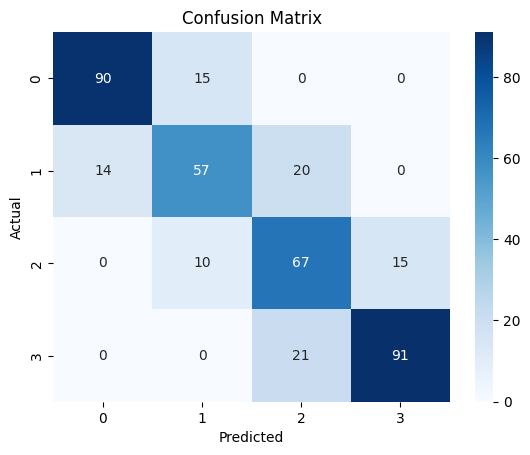

In [22]:
X_train = X_train[["ram"]]
# Fit Logistic regression in sklearn
from sklearn.linear_model import LogisticRegression
# Multinomial model
model = LogisticRegression(solver='lbfgs', random_state=42, max_iter=1000)
model.fit(X_train, y_train)
# Predict probabilities
y_pred_prob = model.predict_proba(X_test[["ram"]])
# Predict classes
y_pred = model.predict(X_test[["ram"]])
# Evaluate model
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Coefficients: [-6.04339875]
Intercept: -1.902289045827235


/opt/miniconda3/envs/practiceenv/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


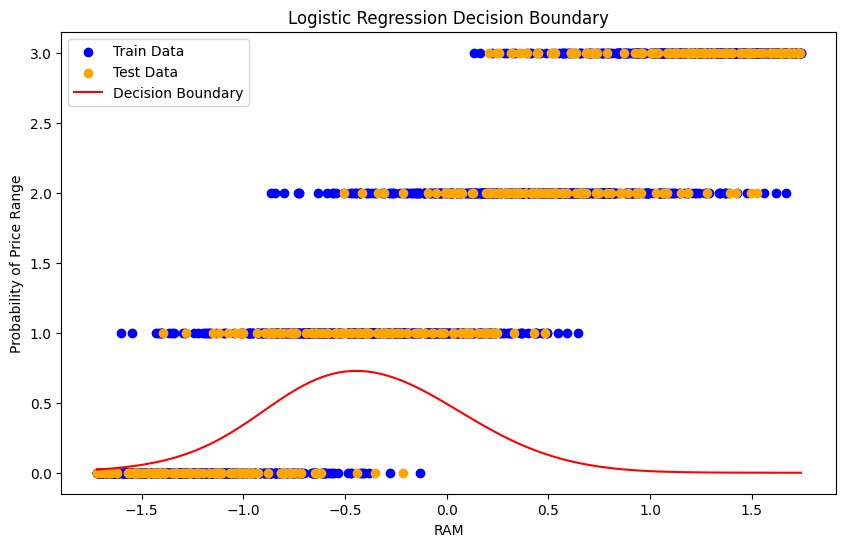

In [23]:
# Extract parameters
params = model.coef_[0]
intercept = model.intercept_[0]
print("Coefficients:", params)
print("Intercept:", intercept)
# Plotting the decision boundary
plt.figure(figsize=(10, 6))
plt.scatter(X_train["ram"], y_train, color='blue', label='Train Data')
plt.scatter(X_test["ram"], y_test, color='orange', label='Test Data')
x_range = np.linspace(X_train["ram"].min(), X_train["ram"].max(), 100)
y_boundary = model.predict_proba(x_range.reshape(-1, 1))[:, 1]
plt.plot(x_range, y_boundary, color='red', label='Decision Boundary')
plt.xlabel("RAM")
plt.ylabel("Probability of Price Range")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

Optimization terminated successfully.
         Current function value: 0.562559
         Iterations 9
                          MNLogit Regression Results                          
Dep. Variable:            price_range   No. Observations:                 1600
Model:                        MNLogit   Df Residuals:                     1594
Method:                           MLE   Df Model:                            3
Date:                Tue, 29 Jul 2025   Pseudo R-squ.:                  0.5941
Time:                        21:15:24   Log-Likelihood:                -900.09
converged:                       True   LL-Null:                       -2217.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
price_range=1       coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
ram               4.9874      0.337     14.788      0.000       4.326       5.648
const             4.

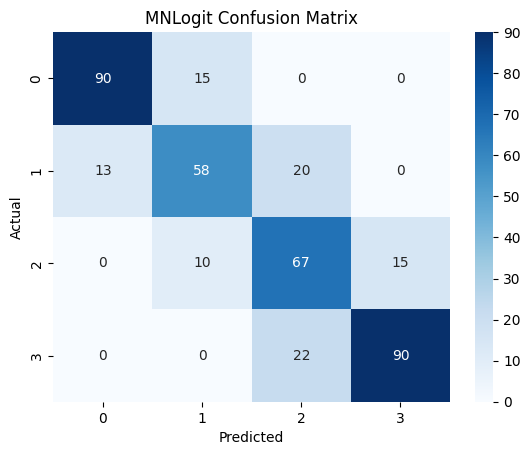

In [32]:
# Fit MNlogit
mnlogit_model = sm.MNLogit(y_train, X_train[["ram", "const"]])
mnlogit_result = mnlogit_model.fit()
print(mnlogit_result.summary())
# Predict probabilities using MNLogit
y_pred_prob_mnlogit = mnlogit_result.predict(X_test[["ram", "const"]])
# Predict classes using MNLogit
y_pred_mnlogit = np.argmax(y_pred_prob_mnlogit, axis=1)
# Evaluate MNLogit model
print(classification_report(y_test, y_pred_mnlogit))
cm_mnlogit = confusion_matrix(y_test, y_pred_mnlogit)
sns.heatmap(cm_mnlogit, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("MNLogit Confusion Matrix")
plt.show()
# Extract parameters from MNLogit